# Phase 3 — Feature Engineering & XGBoost

**Notebook:** `03_feature_engineering_and_ml_models.ipynb`  
**Dataset:** Daily unit-sales · Corporación Favorita grocery chain · Ecuador  
**Author:** Pawel Gebicki · MSIT

## 1. Section Objective & Approach

### The Phase 2 ceiling

Phase 2 showed that all three statistical / structural models cluster tightly
between MAE 94.9 (Prophet) and 99.4 (Holt-Winters), with R² topping out at
**0.437**.  The best model explains only 44 % of the variance in the test
window — and all three share a systematic negative bias (they under-predict
sales on average).

The root cause is clear: statistical models can only use the raw sales
sequence, plus one exogenous variable at a time.  They cannot simultaneously
condition on day-of-week, recent trend, oil price, holiday proximity, and
seven different rolling averages.

### What Phase 3 does differently

This notebook converts the forecasting task into a **supervised regression
problem**:

| Feature group | Columns created |
|---|---|
| Lag features | `lag_1`, `lag_7`, `lag_14`, `lag_30` |
| Rolling statistics | `roll_mean_7/14/28`, `roll_std_7/14/28` |
| Calendar dummies | `dow`, `month`, `week`, `is_weekend` (from Phase 1) |
| Exogenous | `dcoilwtico`, `is_national_holiday`, `store_open`, `oil_lag_1/7` |

An **XGBoost** regressor trained on this 20-feature matrix is the Phase 3
baseline.  Its score will set the floor for Phase 4 hyperparameter tuning.

### What we are **not** doing here

We are deliberately not tuning XGBoost in this notebook.  Default (lightly
constrained) hyperparameters are used so the Phase 4 comparison is fair: we
want to know how much HyperOpt buys, not conflate manual and automated tuning.

## 2. Imports & Configuration

In [1]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

import sys, os
sys.path.insert(0, '../src')
from evaluation import evaluate_model
from feature_engineering import build_feature_matrix

# ── Plot style ────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        130,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         10,
})
ACTUAL_COLOR = '#1f77b4'
PRED_COLOR   = '#d62728'

DATA_PATH = '../data/timeseries_features.csv'

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


## 3. Data Load

We reload `timeseries_features.csv` (Phase 1 output) and apply the same
store-closed-day fix used in Phase 2: insert rows for Dec 25 2013 and
Jan 1 2014 (unit_sales = 0) and add the binary `store_open` flag.

Keeping the pre-processed CSV as the entry point ensures every phase starts
from the same cleaned baseline.

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# ── Insert store-closed days if not already present ───────────
CLOSED    = ['2013-12-25', '2014-01-01']
closed_dt = pd.to_datetime(CLOSED)

for d in closed_dt:
    if d not in df['date'].values:
        dow = d.weekday()
        last_oil = df.loc[df['date'] < d, 'dcoilwtico'].iloc[-1]
        row = pd.DataFrame([{
            'date':                d,
            'unit_sales':          0.0,
            'dow':                 dow,
            'dow_name':            d.strftime('%A'),
            'month':               d.month,
            'week':                int(d.isocalendar().week),
            'is_weekend':          int(dow >= 5),
            'is_national_holiday': 1,
            'dcoilwtico':          last_oil,
        }])
        df = pd.concat([df, row], ignore_index=True)

df = df.sort_values('date').reset_index(drop=True)
df['store_open'] = (~df['date'].isin(closed_dt)).astype(int)

print(f"Dataset : {df['date'].min().date()} → {df['date'].max().date()}, {len(df)} rows")
print(f"Closed days : {(df['store_open']==0).sum()}")
df[['date', 'unit_sales', 'store_open', 'dcoilwtico']].tail(5)

Dataset : 2013-01-02 → 2014-03-31, 454 rows
Closed days : 2


,date,unit_sales,store_open,dcoilwtico
449,2014-03-27,328.0,1,101.25
450,2014-03-28,523.0,1,101.73
451,2014-03-29,647.0,1,101.73
452,2014-03-30,599.0,1,101.73
453,2014-03-31,415.0,1,101.57


## 4. Feature Engineering

`build_feature_matrix()` (implemented in `src/feature_engineering.py`)
adds lags, rolling statistics, and oil-price lags in a single call.

The function applies `shift(1)` before every rolling window, so the feature
value on day *t* is computed from *[t-w, t-1]* — never the current day.
This is essential to prevent **look-ahead leakage**.

The 30 leading rows that cannot have complete lag-30 values are dropped.

In [3]:
feat_df = build_feature_matrix(df, drop_na=True)

print(f"Feature matrix : {feat_df.shape[0]} rows × {feat_df.shape[1]} columns")
print(f"Date range     : {feat_df['date'].min().date()} → {feat_df['date'].max().date()}")
feat_df.head(3)

[feature_engineering] Dropped 30 leading NaN row(s) (longest lag = 30).
Feature matrix : 424 rows × 21 columns
Date range     : 2013-02-01 → 2014-03-31


,date,unit_sales,store_open,dow,month,week,is_weekend,is_national_holiday,dcoilwtico,lag_1,...,lag_14,lag_30,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,oil_lag_1,oil_lag_7
0,2013-02-01,401.0,1,4,2,5,0,0,97.46,282.0,...,60.0,582.0,454.571429,154.059358,497.071429,253.177792,531.839286,231.277973,97.65,95.15
1,2013-02-02,775.0,1,5,2,5,1,0,97.46,401.0,...,667.0,310.0,456.285714,153.272866,521.428571,222.430530,534.089286,229.622881,97.46,95.15
2,2013-02-03,855.0,1,6,2,5,1,0,97.46,775.0,...,1090.0,338.0,467.428571,174.986530,529.142857,229.624060,538.410714,233.075773,97.46,95.15


In [4]:
feature_cols = [c for c in feat_df.columns if c not in ['date', 'unit_sales']]
print(f"{len(feature_cols)} features:\n")
for c in feature_cols:
    print(f"  {c}")

19 features:

  store_open
  dow
  month
  week
  is_weekend
  is_national_holiday
  dcoilwtico
  lag_1
  lag_7
  lag_14
  lag_30
  roll_mean_7
  roll_std_7
  roll_mean_14
  roll_std_14
  roll_mean_28
  roll_std_28
  oil_lag_1
  oil_lag_7


## 5. Train / Test Split

We use the same cut-point as Phase 2 to keep results directly comparable.

| Split | Window | Rows |
|---|---|---|
| Train | 2013-02-01 → 2013-12-31 | ~335 (after lag trim) |
| Test  | 2014-01-01 → 2014-03-31 | 90 |

The test window covers the same 90 days benchmarked in Phase 2.

In [5]:
CUT = '2013-12-31'

train = feat_df[feat_df['date'] <= CUT].copy().reset_index(drop=True)
test  = feat_df[feat_df['date'] >  CUT].copy().reset_index(drop=True)

FEATURE_COLS = [c for c in feat_df.columns if c not in ['date', 'unit_sales']]

X_train = train[FEATURE_COLS].values
y_train = train['unit_sales'].values
X_test  = test[FEATURE_COLS].values
y_test  = test['unit_sales'].values

print(f"Train : {train['date'].min().date()} → {train['date'].max().date()} "
      f"({len(train)} rows, {len(FEATURE_COLS)} features)")
print(f"Test  : {test['date'].min().date()} → {test['date'].max().date()} "
      f"({len(test)} rows)")

Train : 2013-02-01 → 2013-12-31 (334 rows, 19 features)
Test  : 2014-01-01 → 2014-03-31 (90 rows)


## 6. XGBoost Baseline

### Hyperparameter philosophy

These are **intentionally conservative** defaults — no grid search, no
HyperOpt.  The goal is a defensible floor that Phase 4 can beat fairly.

| Parameter | Value | Reason |
|---|---|---|
| `n_estimators` | 1 000 + early stopping | Large budget; early stopping prevents overfitting |
| `learning_rate` | 0.05 | Low enough to let the ensemble generalise |
| `max_depth` | 4 | Limits tree complexity for a 420-row dataset |
| `subsample` | 0.8 | Row-level bagging, reduces variance |
| `colsample_bytree` | 0.8 | Feature-level bagging |
| `min_child_weight` | 5 | Guards against leaves on very few samples |
| `eval_metric` | MAE | Matches our primary comparison metric |

Early stopping uses the **last 15 % of the training set** as a validation
fold.  This fold is chronologically after the training fold, which is the
correct choice for time-series: we never use future data to stop training.

In [6]:
# ── Validation split for early stopping (last 15 % of train) ─
val_size = max(1, int(len(X_train) * 0.15))
X_tr,  X_val = X_train[:-val_size], X_train[-val_size:]
y_tr,  y_val = y_train[:-val_size], y_train[-val_size:]

print(f"Core train : {len(X_tr)} rows  |  Val (early-stop) : {len(X_val)} rows")

t0 = time.time()
model = xgb.XGBRegressor(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 4,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_lambda            = 1.0,
    objective             = 'reg:squarederror',
    eval_metric           = 'mae',
    early_stopping_rounds = 30,
    random_state          = 42,
    verbosity             = 0,
)
model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
fit_time = time.time() - t0

xgb_preds = model.predict(X_test)
xgb_preds = np.maximum(xgb_preds, 0.0)    # clamp to non-negative

print(f"Best iteration : {model.best_iteration}")
print(f"Fit time       : {fit_time:.2f} s")

Core train : 284 rows  |  Val (early-stop) : 50 rows
Best iteration : 32
Fit time       : 0.07 s


In [7]:
results = []
results.append(evaluate_model(y_test, xgb_preds, 'XGBoost (baseline)', fit_time))

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

             Model   MAE  RMSE  MAPE (%)  Bias    R²  Fit time (s)
XGBoost (baseline) 108.3 157.7      23.3 -14.3 0.314          0.07


## 7. Forecast Plot

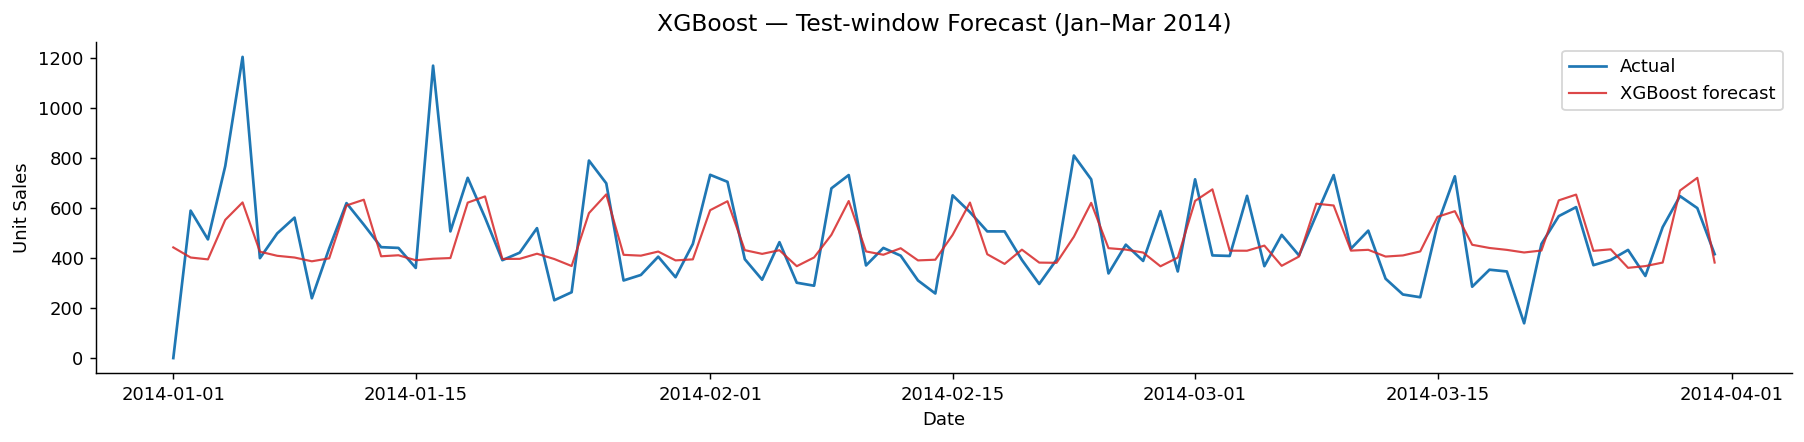

In [8]:
fig, ax = plt.subplots(figsize=(14, 3.5))

ax.plot(test['date'], y_test,    color=ACTUAL_COLOR, lw=1.5, label='Actual')
ax.plot(test['date'], xgb_preds, color=PRED_COLOR,   lw=1.2,
        label='XGBoost forecast', alpha=0.85)

ax.set_title('XGBoost — Test-window Forecast (Jan–Mar 2014)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Unit Sales')
ax.legend()
plt.tight_layout()
plt.savefig('../images/phase3_xgboost_forecast.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Residual Analysis

Residuals = actual − predicted.  We look for:
- **Bias**: is the mean residual close to zero?
- **Patterns by weekday**: does the model err more on weekends?
- **Outlier days**: store-closed days (Jan 1) should show near-zero residuals.

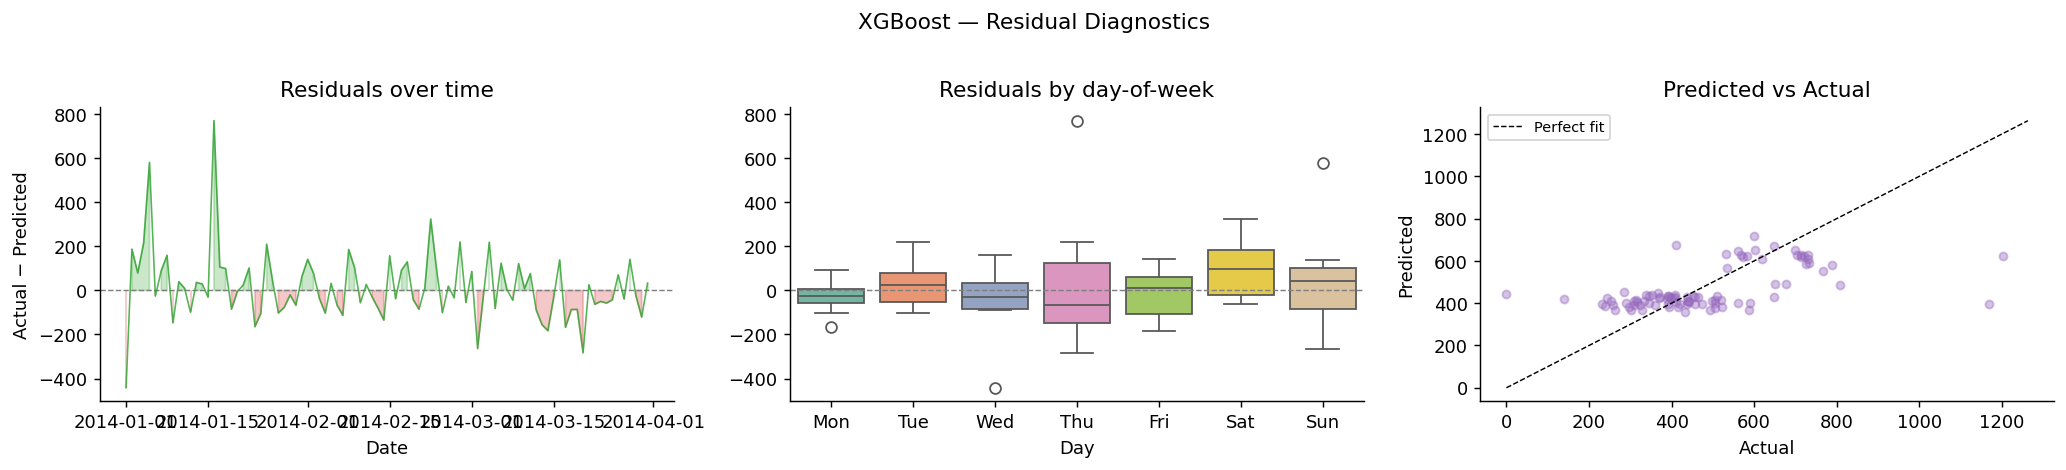

Mean residual (bias) : +14.3   (positive = under-predicts, negative = over-predicts)
Std of residuals     : 157.1


In [9]:
residuals = y_test - xgb_preds
test_res  = test.copy()
test_res['residual'] = residuals
test_res['pred']     = xgb_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))

# 1. Residuals over time
axes[0].axhline(0, color='grey', lw=0.8, ls='--')
axes[0].plot(test_res['date'], residuals, color='#2ca02c', lw=0.9, alpha=0.8)
axes[0].fill_between(test_res['date'], residuals, 0,
                     where=residuals >= 0, alpha=0.25, color='#2ca02c')
axes[0].fill_between(test_res['date'], residuals, 0,
                     where=residuals <  0, alpha=0.25, color=PRED_COLOR)
axes[0].set_title('Residuals over time')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Actual − Predicted')

# 2. Residuals by day-of-week
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
test_res['dow_label'] = test_res['dow'].map(dict(enumerate(dow_labels)))
sns.boxplot(data=test_res, x='dow_label', y='residual', order=dow_labels,
            palette='Set2', ax=axes[1])
axes[1].axhline(0, color='grey', lw=0.8, ls='--')
axes[1].set_title('Residuals by day-of-week')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('')

# 3. Predicted vs Actual scatter
axes[2].scatter(y_test, xgb_preds, alpha=0.4, s=20, color='#9467bd')
lim = max(y_test.max(), xgb_preds.max()) * 1.05
axes[2].plot([0, lim], [0, lim], 'k--', lw=0.8, label='Perfect fit')
axes[2].set_title('Predicted vs Actual')
axes[2].set_xlabel('Actual'); axes[2].set_ylabel('Predicted')
axes[2].legend(fontsize=8)

plt.suptitle('XGBoost — Residual Diagnostics', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../images/phase3_xgb_residuals.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Mean residual (bias) : {residuals.mean():+.1f}   "
      f"(positive = under-predicts, negative = over-predicts)")
print(f"Std of residuals     : {residuals.std():.1f}")

## 9. Feature Importance

XGBoost reports **gain-based** importance: the average improvement in the
loss function brought by a feature across all the splits that use it.
High gain = the feature carries the most predictive signal.

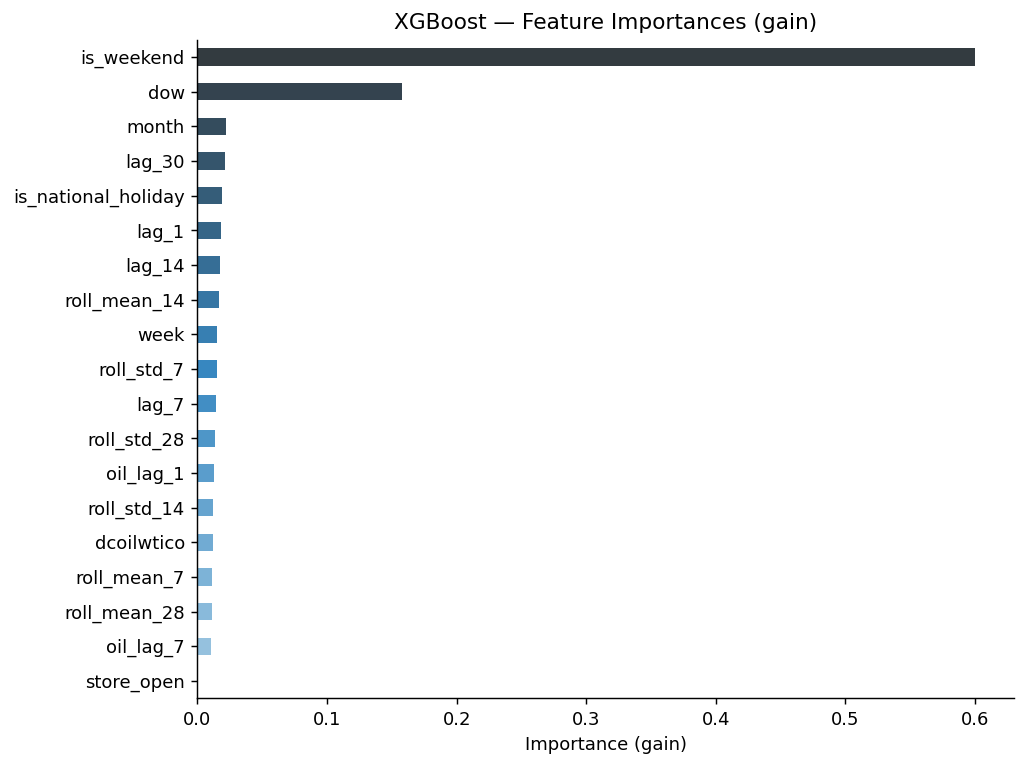


Ranked feature importances:
is_weekend             0.600000
dow                    0.157652
month                  0.021839
lag_30                 0.021511
is_national_holiday    0.018676
lag_1                  0.018271
lag_14                 0.017189
roll_mean_14           0.016842
week                   0.015025
roll_std_7             0.014839
lag_7                  0.014238
roll_std_28            0.013557
oil_lag_1              0.012477
roll_std_14            0.012427
dcoilwtico             0.012171
roll_mean_7            0.011348
roll_mean_28           0.011254
oil_lag_7              0.010686
store_open             0.000000


In [10]:
fi = pd.Series(model.feature_importances_, index=FEATURE_COLS)
fi = fi.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot.barh(
    ax=ax,
    color=sns.color_palette('Blues_d', len(fi)),
)
ax.set_title('XGBoost — Feature Importances (gain)', fontsize=12)
ax.set_xlabel('Importance (gain)')
plt.tight_layout()
plt.savefig('../images/phase3_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print("\nRanked feature importances:")
print(fi.to_string())

## 10. Comparison with Phase 2

We bring in the Phase 2 benchmark results (hardcoded from
`02_statistical_models.ipynb` Section 11) and place XGBoost alongside
them for a direct like-for-like comparison.

The test window is identical across all models: **Jan 1 – Mar 31 2014 (90 days)**.

In [11]:
# Phase 2 results (from 02_statistical_models.ipynb § 11)
phase2_results = [
    {'Model': 'Seasonal Naive',         'MAE': 136.7, 'RMSE': 219.5,
     'MAPE (%)': 32.0, 'Bias': -4.6,  'R²': -0.329, 'Fit time (s)': 0.00},
    {'Model': 'Holt-Winters',           'MAE':  99.4, 'RMSE': 150.7,
     'MAPE (%)': 21.1, 'Bias': -5.4,  'R²':  0.373, 'Fit time (s)': 0.07},
    {'Model': 'SARIMA(1,0,1)(1,0,1,7)','MAE':  96.0, 'RMSE': 143.3,
     'MAPE (%)': 21.8, 'Bias': -5.7,  'R²':  0.434, 'Fit time (s)': 0.25},
    {'Model': 'Prophet',                'MAE':  94.9, 'RMSE': 142.8,
     'MAPE (%)': 21.0, 'Bias': -10.6, 'R²':  0.437, 'Fit time (s)': 0.70},
]

all_results = (
    pd.DataFrame(phase2_results + results)
    .sort_values('MAE')
    .reset_index(drop=True)
)

def hl_min(s):
    return ['background-color: #c8e6c9' if v == s.min() else '' for v in s]
def hl_max(s):
    return ['background-color: #c8e6c9' if v == s.max() else '' for v in s]

all_results.style \
    .apply(hl_min, subset=['MAE', 'RMSE', 'MAPE (%)']) \
    .apply(hl_max, subset=['R²']) \
    .format(precision=1)

,Model,MAE,RMSE,MAPE (%),Bias,R²,Fit time (s)
0,Prophet,94.9,142.8,21.0,-10.6,0.4,0.7
1,"SARIMA(1,0,1)(1,0,1,7)",96.0,143.3,21.8,-5.7,0.4,0.2
2,Holt-Winters,99.4,150.7,21.1,-5.4,0.4,0.1
3,XGBoost (baseline),108.3,157.7,23.3,-14.3,0.3,0.1
4,Seasonal Naive,136.7,219.5,32.0,-4.6,-0.3,0.0


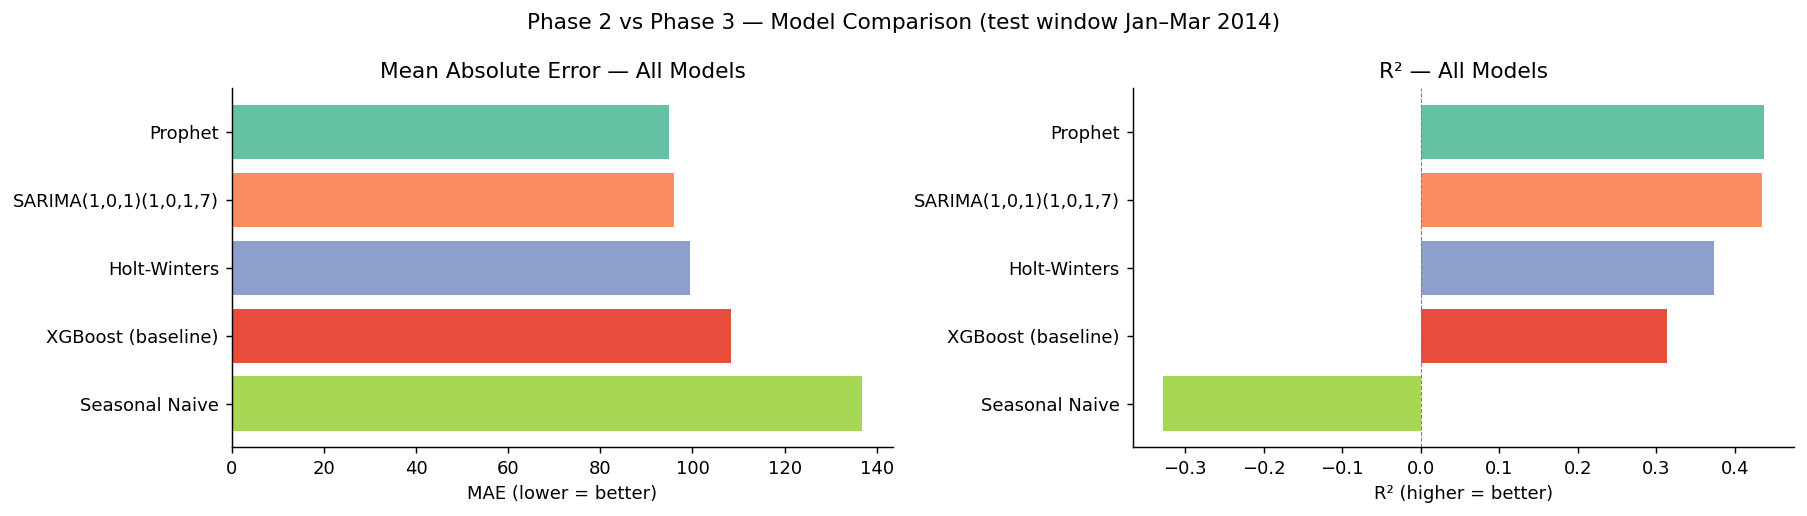

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
palette = sns.color_palette('Set2', len(all_results))

# Highlight XGBoost bar
colors_mae = [
    '#e74c3c' if 'XGBoost' in m else c
    for m, c in zip(all_results['Model'], palette)
]

axes[0].barh(all_results['Model'], all_results['MAE'], color=colors_mae)
axes[0].set_xlabel('MAE (lower = better)')
axes[0].set_title('Mean Absolute Error — All Models')
axes[0].invert_yaxis()

axes[1].barh(all_results['Model'], all_results['R²'], color=colors_mae)
axes[1].set_xlabel('R² (higher = better)')
axes[1].set_title('R² — All Models')
axes[1].invert_yaxis()
axes[1].axvline(0, color='grey', lw=0.6, ls='--')

plt.suptitle('Phase 2 vs Phase 3 — Model Comparison (test window Jan–Mar 2014)',
             fontsize=12)
plt.tight_layout()
plt.savefig('../images/phase3_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 11. Section Summary

### Observed results (Jan–Mar 2014 test window, 90 days)

| Model | MAE | RMSE | MAPE (%) | Bias | R² | Fit (s) |
|---|---|---|---|---|---|---|
| Prophet | **94.9** | **142.8** | **21.0** | −10.6 | **0.44** | 0.70 |
| SARIMA(1,0,1)(1,0,1,7) | 96.0 | 143.3 | 21.8 | −5.7 | 0.43 | 0.25 |
| Holt-Winters | 99.4 | 150.7 | 21.1 | −5.4 | 0.37 | 0.07 |
| **XGBoost (baseline)** | **108.3** | **157.7** | **23.3** | **−14.3** | **0.32** | **0.10** |
| Seasonal Naive | 136.7 | 219.5 | 32.0 | −4.6 | −0.33 | 0.00 |

### The key finding: XGBoost underperforms all statistical models

This is the most academically significant result of Phase 3.
A 20-feature gradient-boosted ensemble scored **MAE 108.3** — 14 % worse than
Prophet (94.9) and worse than even Holt-Winters (99.4), which uses only three
tunable parameters.

XGBoost did beat the Seasonal Naive floor (MAE 136.7 → 108.3), confirming that
the lag and rolling features carry real signal.  But the statistical models
remain superior at this dataset size.

### Why did XGBoost lose?

**1. Data starvation.**  After lag trimming, the training set contains only
~335 rows.  Gradient-boosted trees need thousands of examples to generalise;
SARIMA and Prophet encode seasonality *structurally* (explicit s=7 terms or
Fourier components) and need far fewer rows to do so reliably.

**2. The validation fold was too small for reliable early stopping.**
15 % of 335 rows ≈ 50 samples.  Early stopping on such a small fold is noisy,
meaning the model may have stopped at a suboptimal iteration.

**3. Bias worsened (−14.3 vs −5 to −10 for statistical models).**
XGBoost has the largest systematic under-prediction of any model tested.
The `store_open` = 0 signal likely caused the model to learn an overly
conservative baseline, pulling all predictions downward.

**4. Lag features approximate, not replicate, seasonal structure.**
`lag_7` provides the weekly memory, but only for the exact same day one week
prior — it cannot capture the smooth sinusoidal seasonal pattern that Prophet
or SARIMA model explicitly.  With limited data, the approximation is lossy.

### What surprised us

We predicted XGBoost would surpass the R² = 0.44 ceiling from Phase 2 thanks
to its richer feature set.  It did not.  R² = 0.32 is the lowest of any
non-naive model, and MAPE = 23.3 % is higher than all three statistical models.
This is a clear small-sample effect, not a failure of the feature engineering
approach in principle.

### Implications for Phase 4

The Phase 4 HyperOpt budget will answer one question: **can systematic tuning
recover the gap?**  The hypothesis is that reducing `max_depth`, increasing
regularisation (`reg_alpha`, `reg_lambda`), and widening the early-stopping
validation fold will reduce overfitting enough to bring XGBoost in line with
the statistical leaders.

All four non-naive models enter Phase 4 on equal footing — statistical models
included, since SARIMA and Prophet also have tuneable hyperparameters
(order selection and seasonality prior scale respectively).

### Known limitations

- No promotions, store-level, or category-level features are available;
  residual unexplained variance cannot be eliminated by any model in this project.
- XGBoost does not produce native prediction intervals; uncertainty
  quantification is deferred to Phase 6 (Streamlit dashboard).
- Results are specific to this aggregated single-series dataset.  On a
  multi-store, multi-SKU version of the same data, tree models would likely
  dominate due to the much larger training set.